In [1]:
import pandas as pd
from io import StringIO

# ==============================
# Paste your CSV text here
# ==============================
# csv_text = """
# run_id,router,lambda_score,arrival_rate,pattern_type,num_prompts,num_completed,avg_ttft_real,avg_tpot_real,avg_latency_real,avg_p_tokens,avg_d_tokens,overall_avg_running,overall_avg_waiting,overall_avg_kv_cache,model_Qwen2.5-14B-Instruct_avg_running,model_Qwen2.5-14B-Instruct_avg_waiting,model_Qwen2.5-14B-Instruct_avg_kv_cache,model_Phi-3-mini-128k-instruct_avg_running,model_Phi-3-mini-128k-instruct_avg_waiting,model_Phi-3-mini-128k-instruct_avg_kv_cache,model_Llama-3.1-8B-Instruct_avg_running,model_Llama-3.1-8B-Instruct_avg_waiting,model_Llama-3.1-8B-Instruct_avg_kv_cache,model_Qwen2.5-3B-Instruct_avg_running,model_Qwen2.5-3B-Instruct_avg_waiting,model_Qwen2.5-3B-Instruct_avg_kv_cache,model_Mistral-7B-Instruct-v0.3_avg_running,model_Mistral-7B-Instruct-v0.3_avg_waiting,model_Mistral-7B-Instruct-v0.3_avg_kv_cache,gpu_0_avg_running,gpu_0_avg_waiting,gpu_0_avg_kv_cache,gpu_1_avg_running,gpu_1_avg_waiting,gpu_1_avg_kv_cache,dispatch_count_model_Qwen2.5-3B-Instruct,dispatch_count_model_Llama-3.1-8B-Instruct,dispatch_count_model_Mistral-7B-Instruct-v0.3,dispatch_count_gpu_1,dispatch_count_gpu_0
# 20251117-203330,carrot,0.5,15.0,sustained,1685,1685,12.804855361961115,0.030259402959137382,23.480048904928328,1944.4611275964392,334.553115727003,3.567455621301775,4.174161735700197,0.18431217504485667,0.0,0.0,0.0,0.0,0.0,0.0,11.617357001972387,20.870808678500985,0.8930835020695799,6.050295857988166,0.0,0.027992388813646272,0.16962524654832348,0.0,0.00048498434105712497,0.0,0.0,0.0,5.945759368836292,6.956936226166995,0.30718695840809446,1100,561,24,1685,0
# 20251117-205023,carrot,0.5,18.0,sustained,1685,1685,12.081567154440044,0.030054972257169354,22.667782342327808,1944.4611275964392,330.3994065281899,3.6615541922290387,4.088139059304703,0.18365016969752512,0.0,0.0,0.0,0.0,0.0,0.0,11.858895705521473,20.44069529652352,0.8868437858242818,6.284253578732106,0.0,0.03096605775409539,0.16462167689161555,0.0,0.0004410049092484629,0.0,0.0,0.0,6.102590320381731,6.813565098841172,0.30608361616254187,1100,561,24,1685,0
# 20251117-210641,carrot,0.5,21.0,sustained,1685,1685,13.570263133204655,0.029583800263719755,24.23540028323052,1944.4611275964392,336.0528189910979,3.4539196940726575,4.30038240917782,0.18371576407967355,0.0,0.0,0.0,0.0,0.0,0.0,11.35755258126195,21.50095602294455,0.8911478027043198,5.762906309751434,0.0009560229445506692,0.027023995920189437,0.1491395793499044,0.0,0.0004070217738582772,0.0,0.0,0.0,5.75653282345443,7.167304015296367,0.3061929401327892,1100,561,24,1685,0
# 20251117-212408,hw,0.5,15.0,sustained,1685,1685,2.104201537140753,0.03197872390299143,11.154483345637336,1944.4611275964392,294.71157270029676,6.0367906066536206,1.173385518590998,0.3624883483961343,4.545988258317025,4.908023483365949,0.7368340818213949,1.528375733855186,0.9315068493150684,0.4932598576877006,0.273972602739726,0.0,0.016312879977701797,11.279843444227005,0.023483365949119372,0.3270659177872813,12.555772994129159,0.003913894324853229,0.2389690047065928,3.0371819960861055,2.919765166340509,0.6150469697545478,8.036529680365296,0.0091324200913242,0.19411593415719197,747,10,706,1463,222
# 20251117-213241,hw,0.5,18.0,sustained,1685,1685,2.0906161279989632,0.03157322462654331,10.940566514153863,1944.4611275964392,290.53768545994063,6.143788187372709,1.204887983706721,0.3642043066316384,4.684317718940937,5.6578411405295315,0.7699126692466708,1.6089613034623218,0.35234215885947046,0.4669515300433878,0.29124236252545826,0.0,0.01754973264819603,11.4969450101833,0.006109979633401222,0.2955045357253386,12.637474541751528,0.008146639511201629,0.27110306549459867,3.1466395112016294,3.005091649694501,0.6184320996450294,8.141887304820095,0.0047522063815342835,0.19471911128937777,753,9,689,1451,234
# 20251117-214053,hw,0.5,21.0,sustained,1685,1685,2.120152933166006,0.03116918188203556,11.02422139722445,1944.4611275964392,292.99762611275963,6.095774647887324,1.2269617706237426,0.3609615114200354,4.780684104627767,5.674044265593562,0.7866895545227511,1.7223340040241448,0.4386317907444668,0.43160527293059714,0.28169014084507044,0.0,0.016853990822114,11.293762575452716,0.008048289738430584,0.30700545138106694,12.400402414486921,0.014084507042253521,0.26265328744364813,3.2515090543259557,3.056338028169014,0.609147413726674,7.99195171026157,0.007377598926894702,0.19550424321560966,754,10,690,1454,231
# """

csv_text = """
run_id,router,lambda_score,arrival_rate,pattern_type,num_prompts,num_completed,avg_ttft_real,avg_tpot_real,avg_latency_real,avg_p_tokens,avg_d_tokens,overall_avg_running,overall_avg_waiting,overall_avg_kv_cache,model_Qwen2.5-14B-Instruct_avg_running,model_Qwen2.5-14B-Instruct_avg_waiting,model_Qwen2.5-14B-Instruct_avg_kv_cache,model_Phi-3-mini-128k-instruct_avg_running,model_Phi-3-mini-128k-instruct_avg_waiting,model_Phi-3-mini-128k-instruct_avg_kv_cache,model_Llama-3.1-8B-Instruct_avg_running,model_Llama-3.1-8B-Instruct_avg_waiting,model_Llama-3.1-8B-Instruct_avg_kv_cache,model_Qwen2.5-3B-Instruct_avg_running,model_Qwen2.5-3B-Instruct_avg_waiting,model_Qwen2.5-3B-Instruct_avg_kv_cache,model_Mistral-7B-Instruct-v0.3_avg_running,model_Mistral-7B-Instruct-v0.3_avg_waiting,model_Mistral-7B-Instruct-v0.3_avg_kv_cache,gpu_0_avg_running,gpu_0_avg_waiting,gpu_0_avg_kv_cache,gpu_1_avg_running,gpu_1_avg_waiting,gpu_1_avg_kv_cache,dispatch_count_model_Qwen2.5-3B-Instruct,dispatch_count_model_Llama-3.1-8B-Instruct,dispatch_count_model_Mistral-7B-Instruct-v0.3,dispatch_count_gpu_1,dispatch_count_gpu_0
20251117-203330,carrot,0.5,15.0,sustained,1685,1685,12.804855361961115,0.030259402959137382,23.480048904928328,1944.4611275964392,334.553115727003,3.567455621301775,4.174161735700197,0.18431217504485667,0.0,0.0,0.0,0.0,0.0,0.0,11.617357001972387,20.870808678500985,0.8930835020695799,6.050295857988166,0.0,0.027992388813646272,0.16962524654832348,0.0,0.00048498434105712497,0.0,0.0,0.0,5.945759368836292,6.956936226166995,0.30718695840809446,1100,561,24,1685,0
20251117-205023,carrot,0.5,18.0,sustained,1685,1685,12.081567154440044,0.030054972257169354,22.667782342327808,1944.4611275964392,330.3994065281899,3.6615541922290387,4.088139059304703,0.18365016969752512,0.0,0.0,0.0,0.0,0.0,0.0,11.858895705521473,20.44069529652352,0.8868437858242818,6.284253578732106,0.0,0.03096605775409539,0.16462167689161555,0.0,0.0004410049092484629,0.0,0.0,0.0,6.102590320381731,6.813565098841172,0.30608361616254187,1100,561,24,1685,0
20251117-210641,carrot,0.5,21.0,sustained,1685,1685,13.570263133204655,0.029583800263719755,24.23540028323052,1944.4611275964392,336.0528189910979,3.4539196940726575,4.30038240917782,0.18371576407967355,0.0,0.0,0.0,0.0,0.0,0.0,11.35755258126195,21.50095602294455,0.8911478027043198,5.762906309751434,0.0009560229445506692,0.027023995920189437,0.1491395793499044,0.0,0.0004070217738582772,0.0,0.0,0.0,5.75653282345443,7.167304015296367,0.3061929401327892,1100,561,24,1685,0
20251117-212408,hw,0.5,15.0,sustained,1685,1685,2.104201537140753,0.03197872390299143,11.154483345637336,1944.4611275964392,294.71157270029676,6.0367906066536206,1.173385518590998,0.3624883483961343,4.545988258317025,4.908023483365949,0.7368340818213949,1.528375733855186,0.9315068493150684,0.4932598576877006,0.273972602739726,0.0,0.016312879977701797,11.279843444227005,0.023483365949119372,0.3270659177872813,12.555772994129159,0.003913894324853229,0.2389690047065928,3.0371819960861055,2.919765166340509,0.6150469697545478,8.036529680365296,0.0091324200913242,0.19411593415719197,747,10,706,1463,222
20251117-213241,hw,0.5,18.0,sustained,1685,1685,2.0906161279989632,0.03157322462654331,10.940566514153863,1944.4611275964392,290.53768545994063,6.143788187372709,1.204887983706721,0.3642043066316384,4.684317718940937,5.6578411405295315,0.7699126692466708,1.6089613034623218,0.35234215885947046,0.4669515300433878,0.29124236252545826,0.0,0.01754973264819603,11.4969450101833,0.006109979633401222,0.2955045357253386,12.637474541751528,0.008146639511201629,0.27110306549459867,3.1466395112016294,3.005091649694501,0.6184320996450294,8.141887304820095,0.0047522063815342835,0.19471911128937777,753,9,689,1451,234
20251117-214053,hw,0.5,21.0,sustained,1685,1685,2.120152933166006,0.03116918188203556,11.02422139722445,1944.4611275964392,292.99762611275963,6.095774647887324,1.2269617706237426,0.3609615114200354,4.780684104627767,5.674044265593562,0.7866895545227511,1.7223340040241448,0.4386317907444668,0.43160527293059714,0.28169014084507044,0.0,0.016853990822114,11.293762575452716,0.008048289738430584,0.30700545138106694,12.400402414486921,0.014084507042253521,0.26265328744364813,3.2515090543259557,3.056338028169014,0.609147413726674,7.99195171026157,0.007377598926894702,0.19550424321560966,754,10,690,1454,231
20251119-123423,irt,0.5,15.0,sustained,1685,1685,8.483991395684308,0.03855638813627377,21.670663365270688,1944.4611275964392,341.2059347181009,4.795037756202805,2.9644012944983817,0.18566761567099707,0.0,0.0,0.0,0.003236245954692557,0.0,4.445547390379281e-05,20.68284789644013,14.822006472491909,0.8920320867215669,3.2891046386192015,0.0,0.03626153615951465,0.0,0.0,0.0,0.0016181229773462784,0.0,2.2227736951896405e-05,7.990650845019777,4.94066882416397,0.30943120762702714,626,1058,0,1684,1
20251119-124951,irt,0.5,18.0,sustained,1685,1685,9.848828924586583,0.04241945790764569,23.97222298302353,1944.4611275964392,338.1560830860534,4.703326810176125,3.004696673189824,0.18393022048231195,0.0,0.0,0.0,0.00684931506849315,0.0,0.00014393821069491543,20.50293542074364,15.023483365949119,0.8872711271098489,3.006849315068493,0.0,0.03223603709101587,0.0,0.0,0.0,0.003424657534246575,0.0,7.196910534745771e-05,7.836594911937378,5.007827788649706,0.30650238806695496,626,1058,0,1684,1
20251119-130653,irt,0.5,21.0,sustained,1685,1685,8.773756585842778,0.05131002219647441,23.89814187412092,1944.4611275964392,327.2581602373887,4.9884765625,2.5962890625,0.18122168171252093,0.0,0.0,0.0,0.001953125,0.0,2.3433424621804953e-05,21.83984375,12.9716796875,0.8743611849759017,3.1005859375,0.009765625,0.03172379016208127,0.0,0.0,0.0,0.0009765625,0.0,1.1716712310902476e-05,8.3134765625,4.3271484375,0.30202832504599425,626,1058,0,1684,1
"""

# ==============================
# Load CSV from text
# ==============================
df = pd.read_csv(StringIO(csv_text))

df.head()


,run_id,router,lambda_score,arrival_rate,pattern_type,num_prompts,num_completed,avg_ttft_real,avg_tpot_real,avg_latency_real,...,gpu_0_avg_waiting,gpu_0_avg_kv_cache,gpu_1_avg_running,gpu_1_avg_waiting,gpu_1_avg_kv_cache,dispatch_count_model_Qwen2.5-3B-Instruct,dispatch_count_model_Llama-3.1-8B-Instruct,dispatch_count_model_Mistral-7B-Instruct-v0.3,dispatch_count_gpu_1,dispatch_count_gpu_0
0,20251117-203330,carrot,0.5,15.0,sustained,1685,1685,12.804855,0.030259,23.480049,...,0.000000,0.000000,5.945759,6.956936,0.307187,1100,561,24,1685,0
1,20251117-205023,carrot,0.5,18.0,sustained,1685,1685,12.081567,0.030055,22.667782,...,0.000000,0.000000,6.102590,6.813565,0.306084,1100,561,24,1685,0
2,20251117-210641,carrot,0.5,21.0,sustained,1685,1685,13.570263,0.029584,24.235400,...,0.000000,0.000000,5.756533,7.167304,0.306193,1100,561,24,1685,0
3,20251117-212408,hw,0.5,15.0,sustained,1685,1685,2.104202,0.031979,11.154483,...,2.919765,0.615047,8.036530,0.009132,0.194116,747,10,706,1463,222
4,20251117-213241,hw,0.5,18.0,sustained,1685,1685,2.090616,0.031573,10.940567,...,3.005092,0.618432,8.141887,0.004752,0.194719,753,9,689,1451,234


In [2]:
# Make router names pretty
df["router_pretty"] = df["router"].map({
    "carrot": "CARROT",
    "hw": "HW-Router",
    "irt": "IRT-Router"
})

# Keep only needed columns
plot_df = df[[
    "arrival_rate",
    "router_pretty",
    "overall_avg_running",
    "overall_avg_waiting"
]].sort_values(["arrival_rate", "router_pretty"])

plot_df


,arrival_rate,router_pretty,overall_avg_running,overall_avg_waiting
0,15.0,CARROT,3.567456,4.174162
3,15.0,HW-Router,6.036791,1.173386
6,15.0,IRT-Router,4.795038,2.964401
1,18.0,CARROT,3.661554,4.088139
4,18.0,HW-Router,6.143788,1.204888
7,18.0,IRT-Router,4.703327,3.004697
2,21.0,CARROT,3.453920,4.300382
5,21.0,HW-Router,6.095775,1.226962
8,21.0,IRT-Router,4.988477,2.596289


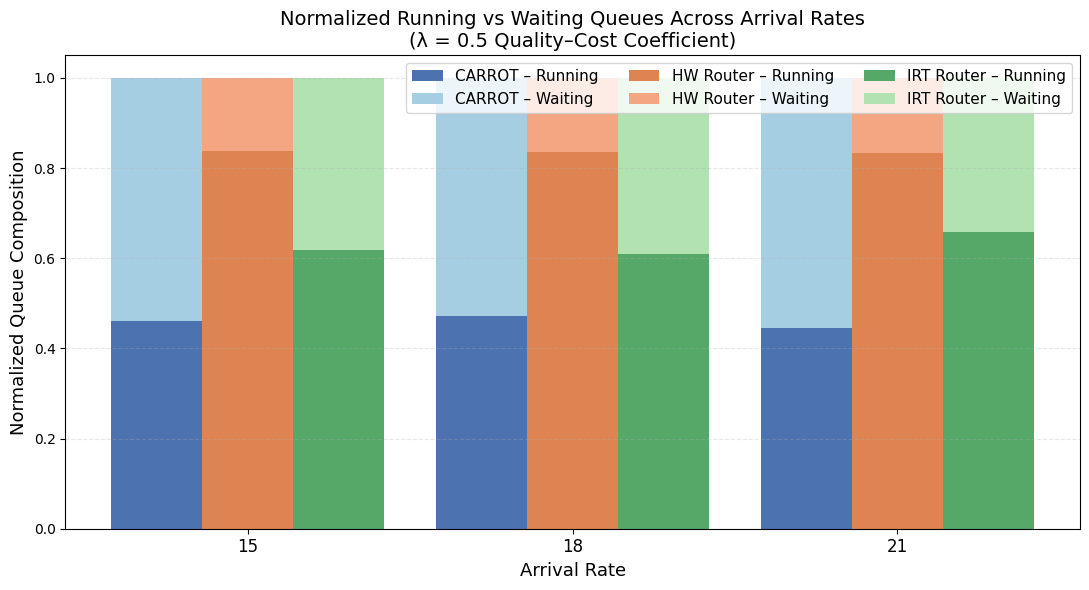

In [3]:
import numpy as np
import matplotlib.pyplot as plt

arrival_rates = sorted(df["arrival_rate"].unique())

carrot = df[df["router"] == "carrot"].sort_values("arrival_rate")
hw     = df[df["router"] == "hw"].sort_values("arrival_rate")
irt    = df[df["router"] == "irt"].sort_values("arrival_rate")

# =============================
# Correct normalization
# =============================
carrot_run  = carrot["overall_avg_running"] / (carrot["overall_avg_running"] + carrot["overall_avg_waiting"])
carrot_wait = 1 - carrot_run

hw_run      = hw["overall_avg_running"] / (hw["overall_avg_running"] + hw["overall_avg_waiting"])
hw_wait     = 1 - hw_run

irt_run     = irt["overall_avg_running"] / (irt["overall_avg_running"] + irt["overall_avg_waiting"])
irt_wait    = 1 - irt_run

labels = [f"{int(a)}" for a in arrival_rates]
x = np.arange(len(arrival_rates))

width = 0.28   # smaller width to fit 3 routers cleanly

plt.figure(figsize=(11,6))

# =============================
# CARROT (Blue)
# =============================
plt.bar(x - width, carrot_run,  width, label="CARROT – Running", color="#4C72B0")
plt.bar(x - width, carrot_wait, width, bottom=carrot_run, label="CARROT – Waiting", color="#A6CEE3")

# =============================
# HW Router (Orange)
# =============================
plt.bar(x, hw_run,  width, label="HW Router – Running", color="#DD8452")
plt.bar(x, hw_wait, width, bottom=hw_run, label="HW Router – Waiting", color="#F4A582")

# =============================
# IRT Router (Green)
# =============================
plt.bar(x + width, irt_run,  width, label="IRT Router – Running", color="#55A868")
plt.bar(x + width, irt_wait, width, bottom=irt_run, label="IRT Router – Waiting", color="#B2E2B2")

# =============================

plt.xticks(x, labels, fontsize=12)
plt.ylabel("Normalized Queue Composition", fontsize=13)
plt.xlabel("Arrival Rate", fontsize=13)

plt.title(
    "Normalized Running vs Waiting Queues Across Arrival Rates\n(λ = 0.5 Quality–Cost Coefficient)",
    fontsize=14
)

plt.legend(fontsize=11, ncol=3)
plt.grid(axis="y", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()


In [4]:
print(carrot_run) 
print(carrot_wait) 
print(hw_run)  
print(hw_wait)
print(irt_run)
print(irt_wait)

0    0.460815
1    0.472477
2    0.445420
dtype: float64
0    0.539185
1    0.527523
2    0.554580
dtype: float64
3    0.837260
4    0.836040
5    0.832445
dtype: float64
3    0.162740
4    0.163960
5    0.167555
dtype: float64
6    0.617962
7    0.610186
8    0.657697
dtype: float64
6    0.382038
7    0.389814
8    0.342303
dtype: float64


In [5]:
import pandas as pd

cols = [
    "arrival_rate", "router",
    "gpu_0_avg_running", "gpu_1_avg_running",
    "gpu_0_avg_waiting", "gpu_1_avg_waiting",
    "gpu_0_avg_kv_cache", "gpu_1_avg_kv_cache",
]

gpu_df = df[cols].copy()

# Pretty router names
gpu_df["router"] = gpu_df["router"].map({
    "carrot": "CARROT",
    "hw": "HW-Router",
    "irt": "IRT-Router"
})

# ---- Compute totals ----
gpu_df["gpu_0_load"] = gpu_df["gpu_0_avg_running"] + gpu_df["gpu_0_avg_waiting"]
gpu_df["gpu_1_load"] = gpu_df["gpu_1_avg_running"] + gpu_df["gpu_1_avg_waiting"]

gpu_df["avg_load"] = (gpu_df["gpu_0_load"] + gpu_df["gpu_1_load"]) / 2
gpu_df["load_skew"] = (gpu_df["gpu_0_load"] - gpu_df["gpu_1_load"]).abs()

# ---- Sub-metrics for explainability ----
gpu_df["run_skew"] = (gpu_df["gpu_0_avg_running"] - gpu_df["gpu_1_avg_running"]).abs()
gpu_df["wait_skew"] = (gpu_df["gpu_0_avg_waiting"] - gpu_df["gpu_1_avg_waiting"]).abs()

# ---- Final reduced table ----
final_cols = [
    "arrival_rate", "router",
    "avg_load", "load_skew",
    "run_skew", "wait_skew"
]

final_gpu_df = gpu_df[final_cols].sort_values(["arrival_rate", "router"])

final_gpu_df


,arrival_rate,router,avg_load,load_skew,run_skew,wait_skew
0,15.0,CARROT,6.451348,12.902696,5.945759,6.956936
3,15.0,HW-Router,7.001305,2.088715,4.999348,2.910633
6,15.0,IRT-Router,6.466469,12.929702,7.989033,4.940669
1,18.0,CARROT,6.458078,12.916155,6.102590,6.813565
4,18.0,HW-Router,7.149185,1.994908,4.995248,3.000339
7,18.0,IRT-Router,6.423924,12.840998,7.833170,5.007828
2,21.0,CARROT,6.461918,12.923837,5.756533,7.167304
5,21.0,HW-Router,7.153588,1.691482,4.740443,3.048960
8,21.0,IRT-Router,6.320801,12.639648,8.312500,4.327148
